In [3]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib_venn import venn2

In [ ]:
def extract_error_type(task, data):
    if task in ["non_live", "live"]:
        return data["error_type"]
    else:
        return data["error"]["error_type"]

def pretty_print_counts(error_counts):
    for k in sorted(error_counts, key=lambda x: error_counts[x], reverse=True):
        print(f"{k}\t{error_counts[k]}")
    print()

base = Path("score_transformers")
models = ["google_gemma-3-12b-it", "meta-llama_Llama-3.1-8B-Instruct", "Qwen_Qwen3-4B-Instruct-2507", "Qwen_Qwen3-8B"]
# tasks = ["non_live", "live", "multi_turn", "agentic/memory/kv"] # exclude web_search_base regarding very poor performance (max 3%)
task_types = ["multi_turn"] # exclude web_search_base regarding very poor performance (max 3%)

for model in models:
    for task_type in task_types:
        for file in os.listdir(base / model / task_type):
            if os.path.isdir(base / model / task_type / file):
                continue
            
            error_counts = {}
            with open(base / model / task_type / file) as f:
                lines = f.readlines()
                metadata = json.loads(lines[0])
                for l in lines[1:]:
                    error_type = extract_error_type(task_type, json.loads(l))
                    if error_type not in error_counts:
                        error_counts[error_type] = 1
                    else:
                        error_counts[error_type] += 1
                    
                    # dict_keys(['id', 'model_name', 'test_category', 'valid', 'error', 'prompt', 'model_result_raw', 'model_result_decoded', 'possible_answer', 'inference_log'])
                    # if "empty_turn_model" in error_type:
                    #     print(json.loads(l)["prompt"])
                    #     print(json.loads(l)["model_result_raw"])
                    #     print(json.loads(l)["model_result_decoded"])
                    
                metadata['counts'] = error_counts
            
            print(base / model / task_type / file)
            print(metadata)
            pretty_print_counts(error_counts)
            

score_transformers/google_gemma-3-12b-it/multi_turn/BFCL_v4_multi_turn_base_score.json
{'accuracy': 0.12, 'correct_count': 24, 'total_count': 200, 'counts': {'multi_turn:instance_state_mismatch': 49, 'multi_turn:empty_turn_model_response': 105, 'multi_turn:execution_response_mismatch': 22}}
multi_turn:empty_turn_model_response	105
multi_turn:instance_state_mismatch	49
multi_turn:execution_response_mismatch	22

score_transformers/meta-llama_Llama-3.1-8B-Instruct/multi_turn/BFCL_v4_multi_turn_base_score.json
{'accuracy': 0.12, 'correct_count': 24, 'total_count': 200, 'counts': {'multi_turn:instance_state_mismatch': 75, 'multi_turn:force_terminated': 28, 'multi_turn:empty_turn_model_response': 23, 'multi_turn:execution_response_mismatch': 50}}
multi_turn:instance_state_mismatch	75
multi_turn:execution_response_mismatch	50
multi_turn:force_terminated	28
multi_turn:empty_turn_model_response	23

score_transformers/Qwen_Qwen3-4B-Instruct-2507/multi_turn/BFCL_v4_multi_turn_base_score.json
{'ac

google_gemma-3-12b-it / non_live / BFCL_v4_multiple_score.json
meta-llama_Llama-3.1-8B-Instruct / non_live / BFCL_v4_multiple_score.json
Qwen_Qwen3-4B-Instruct-2507 / non_live / BFCL_v4_multiple_score.json
Qwen_Qwen3-8B / non_live / BFCL_v4_multiple_score.json


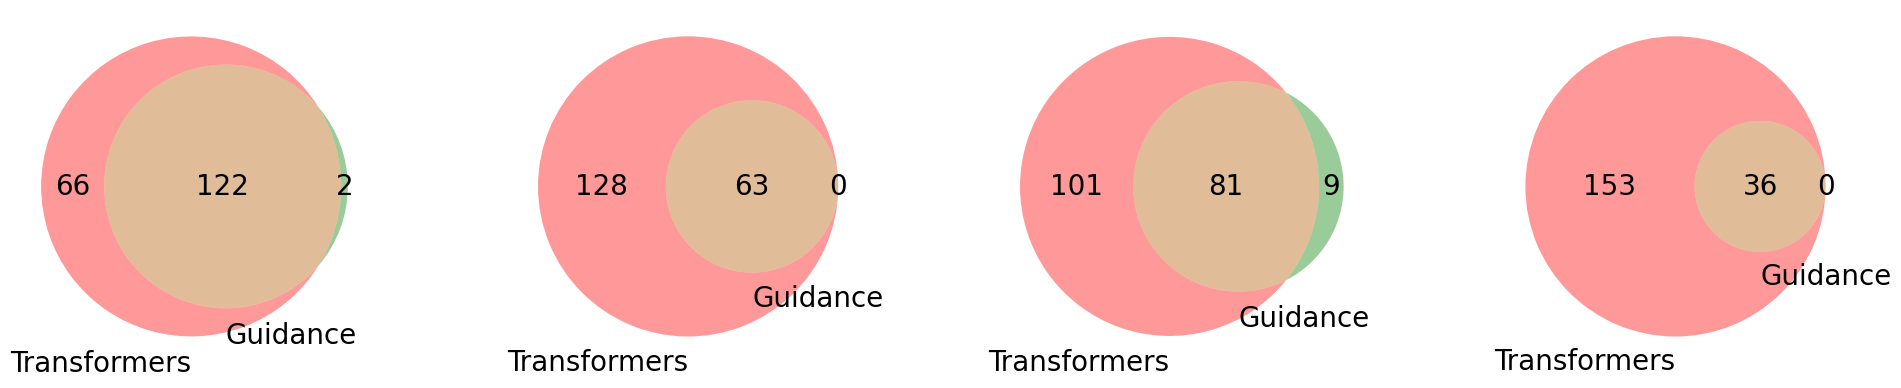

In [20]:
def pretty_print_counts(error_counts):
    for k in sorted(error_counts, key=lambda x: error_counts[x], reverse=True):
        print(f"{k}\t{error_counts[k]}")
    print()

def draw_venn(data):
    _, axes = plt.subplots(1, 4, figsize=(20, 4))

    for ax, (model, both_solved, only_trans, only_guid) in zip(axes, data):
        v = venn2(
            subsets=(only_trans, only_guid, both_solved),
            set_labels=("Transformers", "Guidance"),
            ax=ax
        )
        for label in v.set_labels:
            label.set_fontsize(20)        
        for label in v.subset_labels:
            label.set_fontsize(20)        
        # ax.set_title(f"{model}", fontsize=15)
    
    plt.tight_layout()
    plt.show()

transformers_base = Path("score_transformers")
guidance_base = Path("score_guidance")
models = ["google_gemma-3-12b-it", "meta-llama_Llama-3.1-8B-Instruct", "Qwen_Qwen3-4B-Instruct-2507", "Qwen_Qwen3-8B"]
task_types = ["non_live"] # exclude web_search_base regarding very poor performance (max 3%)
task = "multiple"

data = []

for model in models:
    for task_type in task_types:
        for file in os.listdir(transformers_base / model / task_type):
            if os.path.isdir(transformers_base / model / task_type / file) or task not in file:
                continue
            
            with open(transformers_base / model / task_type / file) as f:
                lines = f.readlines()
                metadata = json.loads(lines[0])
                transformers_unsolved = set()
                for l in lines[1:]:
                    transformers_unsolved.add(json.loads(l)["id"])

            with open(guidance_base / model / task_type / file) as f:
                lines = f.readlines()
                guidance_unsolved = set()
                for l in lines[1:]:
                    guidance_unsolved.add(json.loads(l)["id"])
            
            print(f"{model} / {task_type} / {file}")
            
            both_solved = metadata['total_count'] - len(transformers_unsolved | guidance_unsolved)
            transformer_only = len(guidance_unsolved) - len(transformers_unsolved & guidance_unsolved)
            guidance_only = len(transformers_unsolved) - len(transformers_unsolved & guidance_unsolved)
            
            model_short = model.split('_')[1]
            data.append((model_short, both_solved, transformer_only, guidance_only))
            
draw_venn(data)

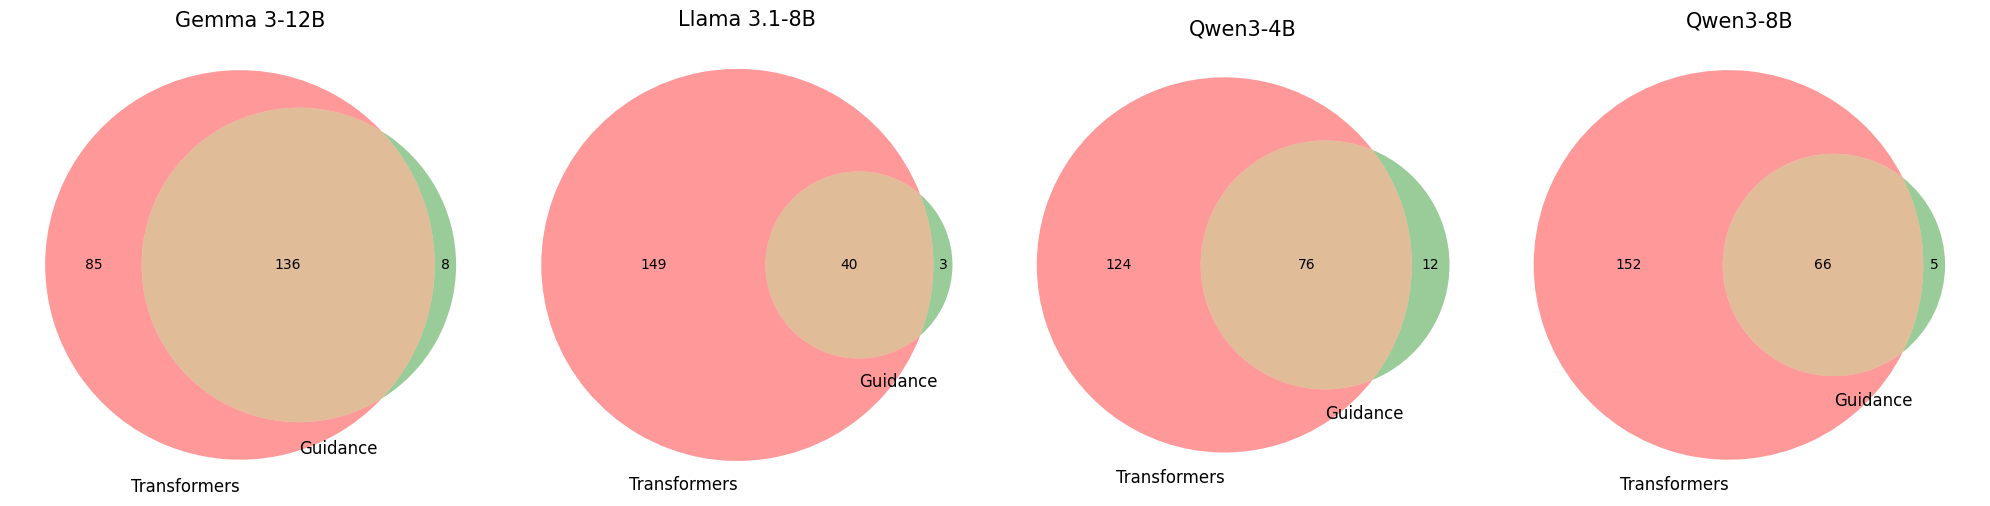

In [ ]:

    

data = [
    ("Gemma 3-12B",       136, 85,  8),
    ("Llama 3.1-8B",       40, 149, 3),
    ("Qwen3-4B",           76, 124, 12),
    ("Qwen3-8B",           66, 152, 5),
]

draw_venn(data)